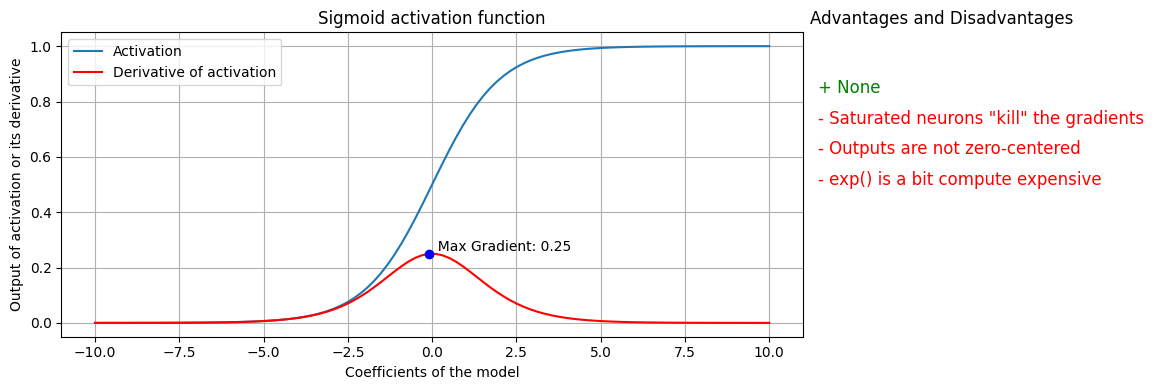

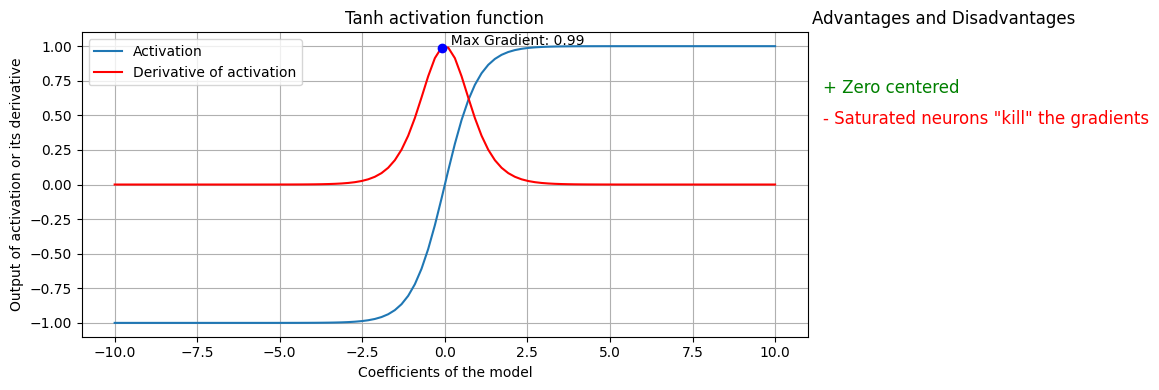

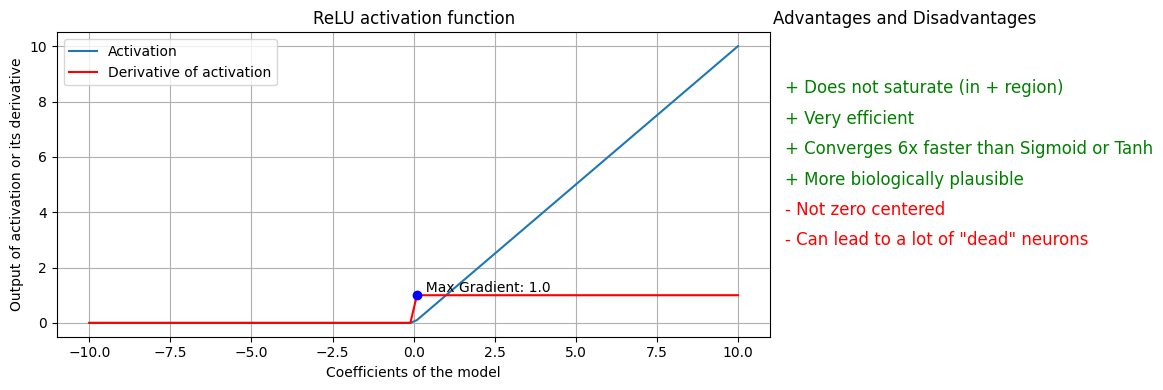

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Define advantages and disadvantages
advantages = {
    'Sigmoid': ['None'],
    'Tanh': ['Zero centered'],
    'ReLU': ['Does not saturate (in + region)', 'Very efficient', 'Converges 6x faster than Sigmoid or Tanh', 'More biologically plausible']
}
disadvantages = {
    'Sigmoid': ['Saturated neurons "kill" the gradients', 'Outputs are not zero-centered', 'exp() is a bit compute expensive'],
    'Tanh': ['Saturated neurons "kill" the gradients'],
    'ReLU': ['Not zero centered', 'Can lead to a lot of "dead" neurons']
}

# Define activation functions and their derivatives
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    t = tanh(x)
    return 1 - t**2

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1.0, 0.0)

# List of functions
functions = [
    (sigmoid, sigmoid_derivative, 'Sigmoid'),
    (tanh, tanh_derivative, 'Tanh'),
    (relu, relu_derivative, 'ReLU')
]

def plot_functions(coefficients):
    for activation, derivative, name in functions:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [3, 1]})

        # Plot the function and its derivative
        activated_coefficients = activation(coefficients)
        derivative_coefficients = derivative(coefficients)

        ax1.plot(coefficients, activated_coefficients, label='Activation')
        ax1.plot(coefficients, derivative_coefficients, color='r', label='Derivative of activation')
        max_index = np.argmax(derivative_coefficients)
        max_x = coefficients[max_index]
        max_y = derivative_coefficients[max_index]
        ax1.plot(max_x, max_y, 'bo')
        ax1.text(max_x, max_y, f'  Max Gradient: {np.round(derivative_coefficients[max_index],2)}', verticalalignment='bottom')
        ax1.set_title(f'{name} activation function')
        ax1.set_xlabel('Coefficients of the model')
        ax1.set_ylabel('Output of activation or its derivative')
        ax1.legend()
        ax1.grid(True)

        # Plot the advantages and disadvantages
        ax2.axis('off')  # hide axes
        ax2.set_title('Advantages and Disadvantages')
        for i, text in enumerate(advantages[name]):
            ax2.text(0, 0.8-i*0.1, '+ ' + text, color='green', transform=ax2.transAxes, fontsize=12)
        for i, text in enumerate(disadvantages[name]):
            ax2.text(0, 0.8-(len(advantages[name])+i)*0.1, '- ' + text, color='red', transform=ax2.transAxes, fontsize=12)
        
        plt.tight_layout()
        plt.show()

coefficients = np.linspace(-10,10, 100)
plot_functions(coefficients)
